*RAW-window-normalize-peaks
*RAW-window-normalize-peaks
*RAW-window-normalize-peaks
*RAW-window-normalize-peaks
*RAW-window-normalize-peaks
*RAW-window-normalize-peaks
*RAW-window-normalize-peaks
*RAW-window-normalize-peaks
*RAW-window-normalize-peaks
*RAW-window-normalize-peaks


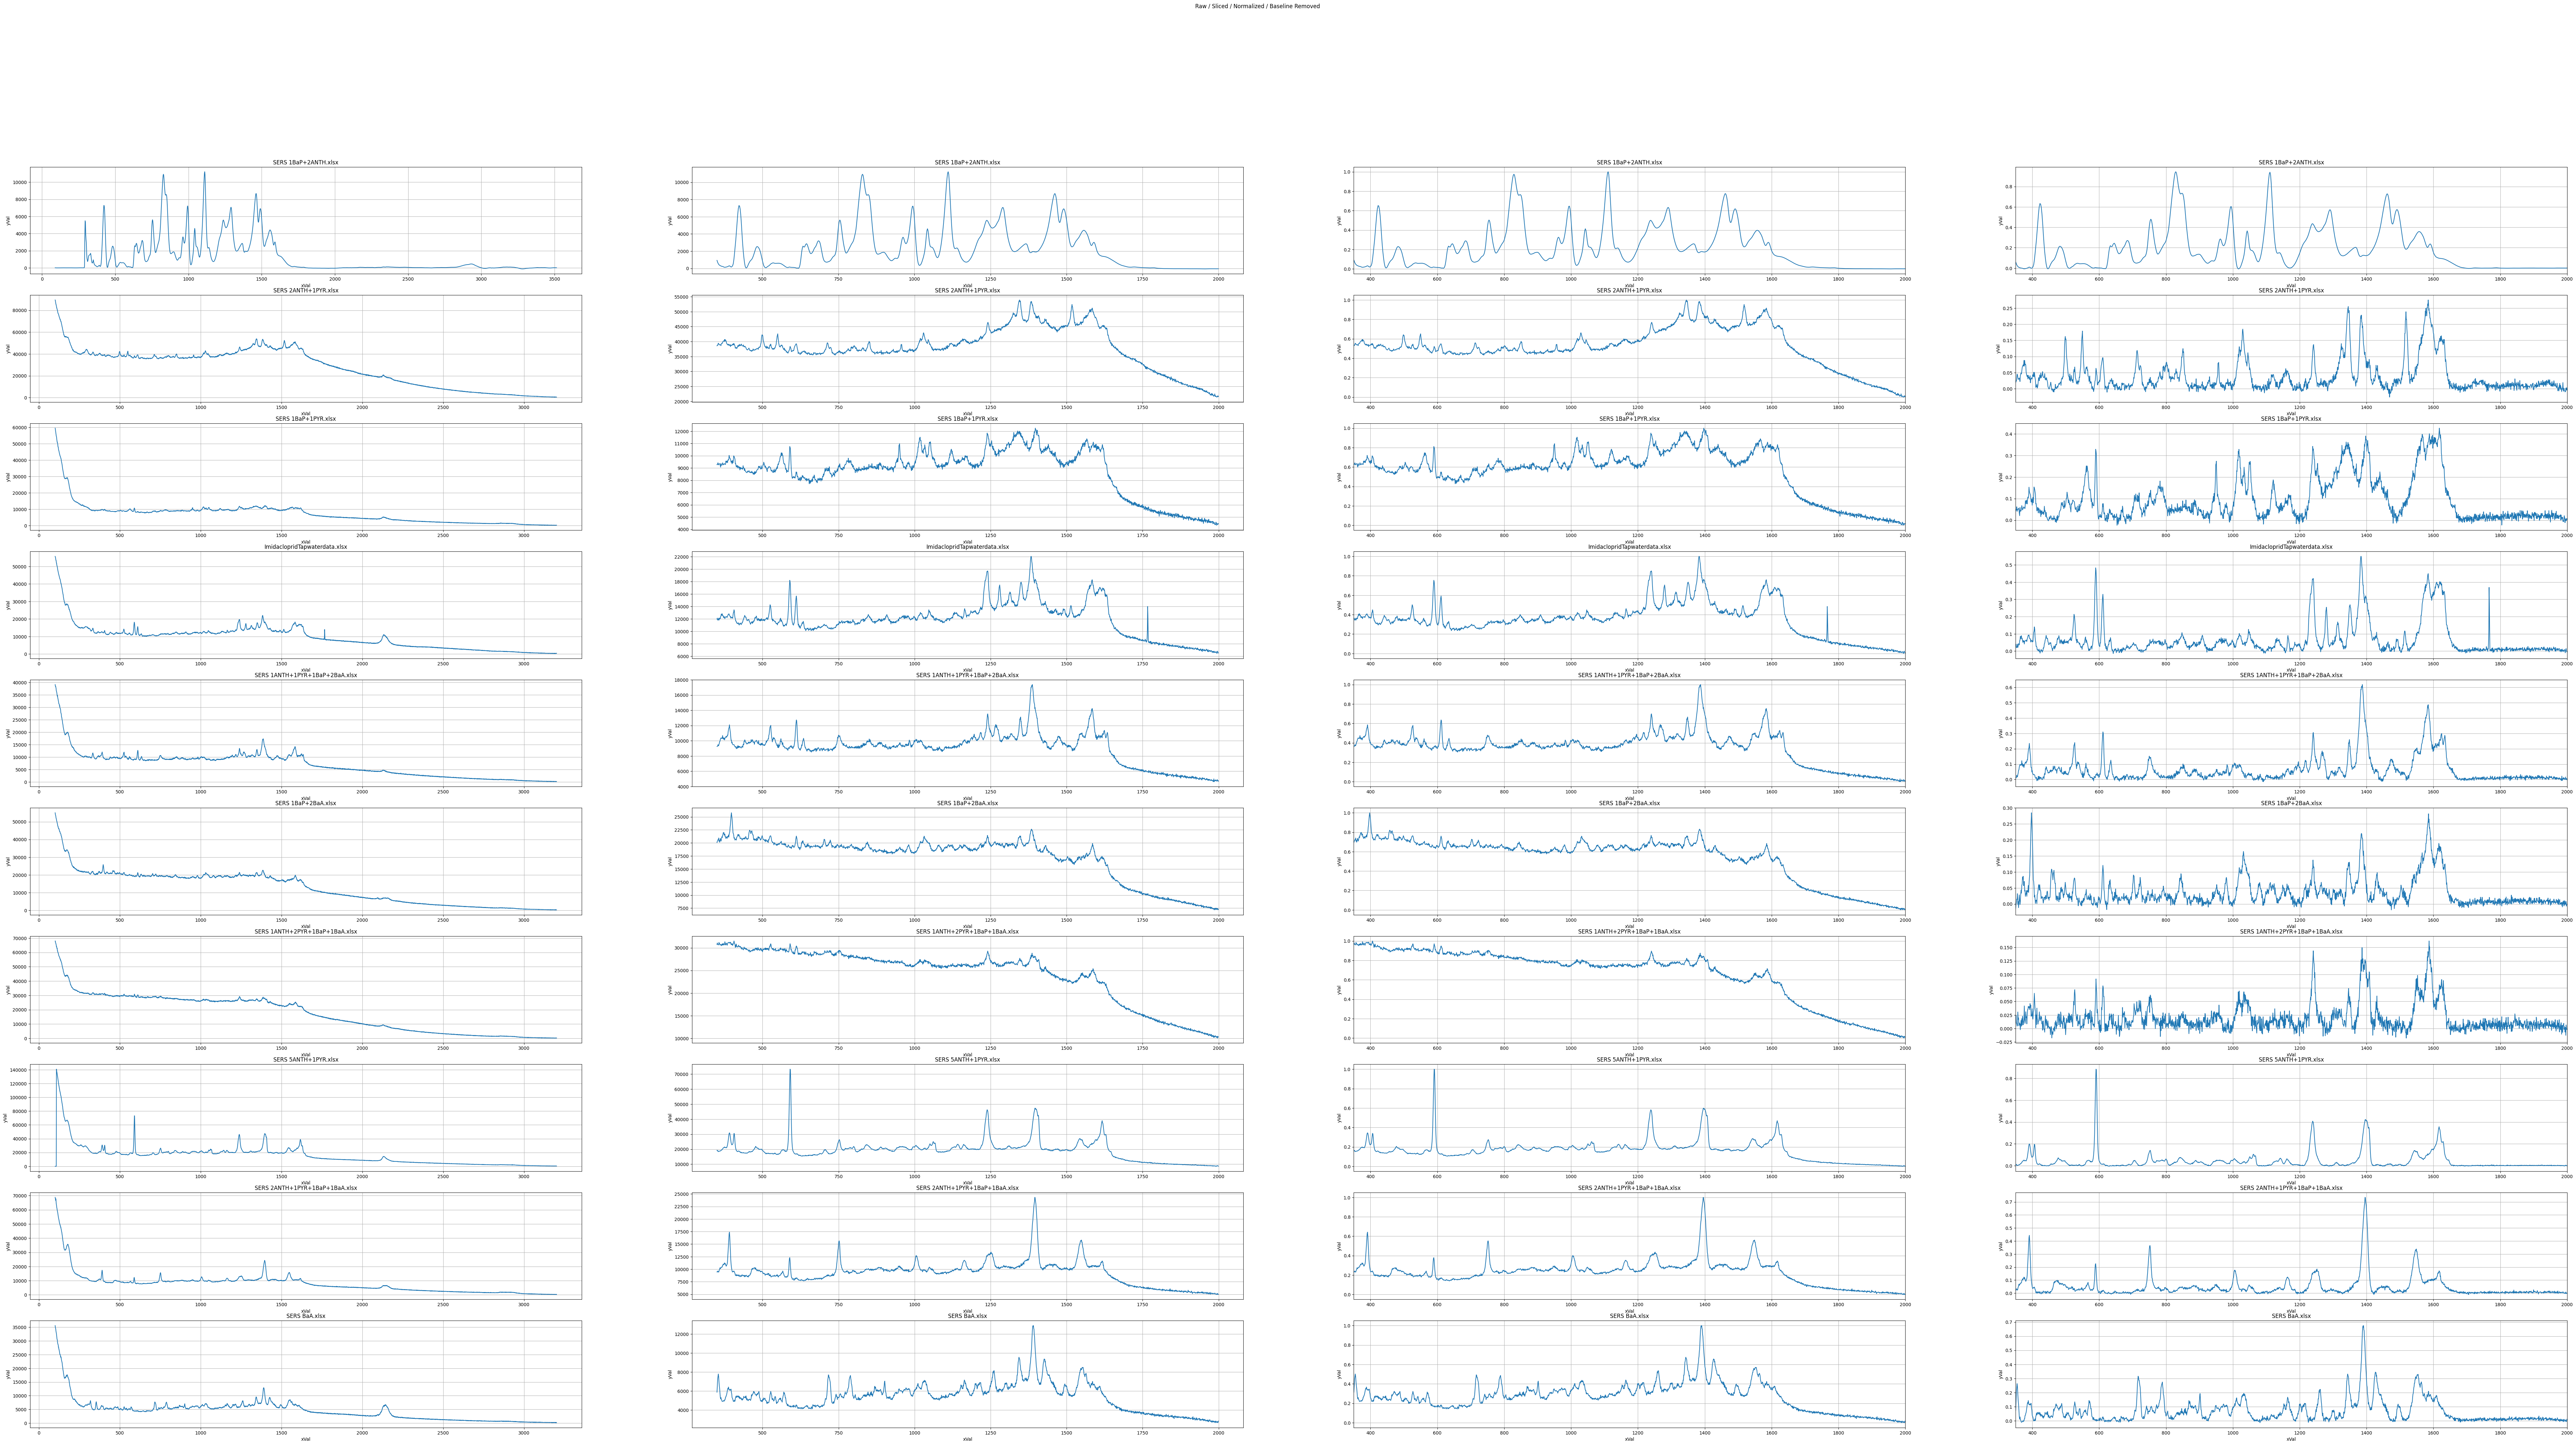

In [4]:
import os
import matplotlib.pyplot as plt
os.chdir("C:\\Users\\23675\\OneDrive - UW-Madison\\Desktop\\research final")

from src.preprocessor import Preprocessor
from BaselineRemoval import BaselineRemoval
import numpy as np
import pandas as pd
# Set working directory
# Directory containing raw datasets
dir = 'raw_dataset'
# List of files to process
files = [
    'SERS 1BaP+2ANTH.xlsx', 'SERS 2ANTH+1PYR.xlsx', 'SERS 1BaP+1PYR.xlsx',
    'ImidaclopridTapwaterdata.xlsx', 'SERS 1ANTH+1PYR+1BaP+2BaA.xlsx',
    'SERS 1BaP+2BaA.xlsx', 'SERS 1ANTH+2PYR+1BaP+1BaA.xlsx',
    'SERS 5ANTH+1PYR.xlsx', 'SERS 2ANTH+1PYR+1BaP+1BaA.xlsx', 'SERS BaA.xlsx'
]

# Load and process raw data
raw_data = []
for file in os.listdir(dir):
    if file in files:
        file_path = os.path.join(dir, file)
        processor = Preprocessor(file_path, m=10, threshold=20, mat_iteration=100, window=1, prominence=0.02)
        raw_x, raw_y = processor.load_raw_data(file_path)
        if file == 'ImidaclopridTapwaterdata.xlsx':
            single_raw_y = raw_y[0]
        else:
            single_raw_y = raw_y[5]
        raw_data.append([raw_x, single_raw_y])

# Initialize plot
plt.figure(figsize=(100, 50))
plt.suptitle('Raw / Sliced / Normalized / Baseline Removed')

# Plot raw data
for i, (raw_x, raw_y) in enumerate(raw_data, start=1):
    plt.subplot(10, 4, 4*i - 3)
    plt.plot(raw_x, raw_y)
    plt.title(files[i-1])
    plt.xlabel('xVal')
    plt.ylabel('yVal')
    plt.grid(True)

# Slice data
sliced_data = []
for (xval, yval) in raw_data:
    sliced = [(x, y) for x, y in zip(xval, yval) if 350 <= x <= 2000]
    sliced_x, sliced_y = zip(*sliced)
    sliced_data.append([sliced_x, sliced_y])

# Plot sliced data
for i, (sliced_x, sliced_y) in enumerate(sliced_data, start=1):
    plt.subplot(10, 4, 4*i-2)
    plt.plot(sliced_x, sliced_y)
    plt.title(files[i-1])
    plt.xlabel('xVal')
    plt.ylabel('yVal')
    plt.grid(True)


normalized_data = []
for sliced_x, sliced_y in sliced_data:
    # Convert sliced_y to a numpy array for easier mathematical operations
    sliced_y = np.array(sliced_y)
    normalized_y = (sliced_y - min(sliced_y)) / (max(sliced_y) - min(sliced_y))
    normalized_data.append([sliced_x, normalized_y])


# Remove baseline from normalized data
baseline_removed_data = []
for x, y in normalized_data:
    baseObj = BaselineRemoval(y)
    baseline_removed_y = baseObj.ZhangFit()
    baseline_removed_data.append([x, baseline_removed_y])

# Plot normalized data
for i, (x, y) in enumerate(normalized_data, start=1):
    plt.subplot(10, 4, 4*i - 1)
    plt.plot(x, y)
    plt.title(files[i-1])
    plt.xlabel('xVal')
    plt.ylabel('yVal')
    plt.grid(True)
    plt.xlim(350, 2000)

# Plot baseline-removed data
for i, (x, y) in enumerate(baseline_removed_data, start=1):
    plt.subplot(10, 4, 4*i)
    plt.plot(x, y)
    plt.title(files[i-1])
    plt.xlabel('xVal')
    plt.ylabel('yVal')
    plt.grid(True)
    plt.xlim(350, 2000)



In [7]:
def create_df_with_nan(x, y, x_start=350, x_end=2000):
    full_x = np.arange(1, x_end+1)
    full_y = np.full_like(full_x, np.nan, dtype=np.float64)
    mask = (x >= x_start) & (x <= x_end)
    # Ensure the indices are calculated correctly within the range of full_x
    for xi, yi in zip(x[mask], y[mask]):
        index = xi - 1 
        if 0 <= index < len(full_y): 
            full_y[index] = yi
    return pd.DataFrame({'xVal': full_x, 'yVal': full_y})

data_frames = {
    'Raw': [create_df_with_nan(np.array(x), np.array(y)) for x, y in raw_data],
    'Sliced': [create_df_with_nan(np.array(x), np.array(y)) for x, y in sliced_data],
    'Normalized': [create_df_with_nan(np.array(x), np.array(y)) for x, y in normalized_data],
    'BaselineRemoved': [create_df_with_nan(np.array(x), np.array(y)) for x, y in baseline_removed_data]
}

# Writing to Excel with multiple sheets
with pd.ExcelWriter('scripts/processed_data_vis.xlsx') as writer:
    for sheet_name, dfs in data_frames.items():
        for i, df in enumerate(dfs):
            # Use a shortened file name to avoid Excel sheet name length limit
            shortened_file_name = files[i].replace('.xlsx', '')[0:15] + (f"_{i+1}" if len(files[i]) > 15 else "")
            df.to_excel(writer, sheet_name=f'{sheet_name}_{shortened_file_name}', index=False)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices